In [3]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [5]:
!git clone https://github.com/GwenONERA/Annotation_ -q

In [6]:
%cd /content/Annotation_

/content/Annotation_


In [7]:
!ls

data		  inference.ipynb	 README.md	   src
Documentation	  outputs		 requirements.txt
experimentations  PerformanceEMOTYC-old  scripts


# ═══════════════════════════════════════════════════════════════
# Phase 1 — Inférence EMOTYC & Métriques Stratifiées
# ═══════════════════════════════════════════════════════════════

In [9]:
# ── 1.1a  Inférence EMOTYC sur EmoTextToKids (données d'entraînement) ──
!python scripts/emotyc_predict.py \
    --xlsx data/emotexttokids_gold_flat.xlsx \
    --out_dir outputs/emotexttokids/emotyc_eval

✓ Gold labels : 27911 lignes chargées depuis emotexttokids_gold_flat.xlsx
  Colonne texte : 'TEXT'
  Colonnes émotions : ['Colère', 'Dégoût', 'Joie', 'Peur', 'Surprise', 'Tristesse', 'Admiration', 'Culpabilité', 'Embarras', 'Fierté', 'Jalousie']
  Colonnes modes : ['Comportementale', 'Désignée', 'Montrée', 'Suggérée']
  Colonne Emo : présente
  Colonnes type : ['Base', 'Complexe']
config.json: 100% 508/508 [00:00<00:00, 1.87MB/s]
tokenizer_config.json: 100% 25.0/25.0 [00:00<00:00, 129kB/s]
sentencepiece.bpe.model: 100% 811k/811k [00:00<00:00, 3.29MB/s]
tokenizer.json: 1.40MB [00:00, 6.29MB/s]
config.json: 1.55kB [00:00, 889kB/s]
model.safetensors: 100% 443M/443M [00:03<00:00, 121MB/s]  
Loading weights: 100% 201/201 [00:00<00:00, 1192.09it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]             
✓ Modèle EMOTYC chargé sur cuda
  19 labels, type=multi_label_classification
▸ Template : bca_v3_no_context
  Exemple  : before:</s>current:Ces dernières semaines, plus

In [10]:
# ── 1.1b  Inférence EMOTYC sur Homophobie (OOD) ──
!python scripts/emotyc_predict.py \
    --xlsx outputs/homophobie/homophobie_annotations_gold_flat.xlsx \
    --out_dir outputs/homophobie/emotyc_eval

✓ Gold labels : 103 lignes chargées depuis homophobie_annotations_gold_flat.xlsx
  Colonne texte : 'TEXT'
  Colonnes émotions : ['Colère', 'Dégoût', 'Joie', 'Peur', 'Surprise', 'Tristesse', 'Admiration', 'Culpabilité', 'Embarras', 'Fierté', 'Jalousie']
  Colonnes modes : ['Comportementale', 'Désignée', 'Montrée', 'Suggérée']
  Colonne Emo : présente
  Colonnes type : ['Base', 'Complexe']
Loading weights: 100% 201/201 [00:00<00:00, 957.66it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
✓ Modèle EMOTYC chargé sur cuda
  19 labels, type=multi_label_classification
▸ Template : bca_v3_no_context
  Exemple  : before:</s>current:Alors julie t'ai dégeulasse de sortir avec une gadji bande de salopes</s>after:</s>…

Inférence sur 103 phrases (batch_size=16)…
✓ Inférence terminée — shape: (103, 19)
▸ Seuils optimisés :
    Colère          : 0.282172
    Dégoût          : 0.192690
    Joie            : 0.915505
    Peur            : 0.988186
    Surprise       

In [11]:
# ── 1.1c  Inférence EMOTYC sur Obésité (OOD) ──
!python scripts/emotyc_predict.py \
    --xlsx outputs/obésité/obésité_annotations_gold_flat.xlsx \
    --out_dir outputs/obésité/emotyc_eval

✓ Gold labels : 373 lignes chargées depuis obésité_annotations_gold_flat.xlsx
  Colonne texte : 'TEXT'
  Colonnes émotions : ['Colère', 'Dégoût', 'Joie', 'Peur', 'Surprise', 'Tristesse', 'Admiration', 'Culpabilité', 'Embarras', 'Fierté', 'Jalousie']
  Colonnes modes : ['Comportementale', 'Désignée', 'Montrée', 'Suggérée']
  Colonne Emo : présente
  Colonnes type : ['Base', 'Complexe']
Loading weights: 100% 201/201 [00:00<00:00, 986.76it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]               
✓ Modèle EMOTYC chargé sur cuda
  19 labels, type=multi_label_classification
▸ Template : bca_v3_no_context
  Exemple  : before:</s>current:Ho pk vous insulter Paul ?</s>after:</s>…

Inférence sur 373 phrases (batch_size=16)…
✓ Inférence terminée — shape: (373, 19)
▸ Seuils optimisés :
    Colère          : 0.282172
    Dégoût          : 0.192690
    Joie            : 0.915505
    Peur            : 0.988186
    Surprise        : 0.972243
    Tristesse       : 0.698449
  

In [12]:
# ══════════════════════════════════════════════════════════════════════
# 1.2  Métriques Stratifiées — par label / densité / profil
# ══════════════════════════════════════════════════════════════════════
import json, os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import f1_score, precision_score, recall_score

# ── Constantes (reproduites de emotyc_predict.py & distribution_analysis.py) ──
LABELS_19 = [
    "Emo",
    "Colère", "Dégoût", "Joie", "Peur", "Surprise", "Tristesse",
    "Admiration", "Culpabilité", "Embarras", "Fierté", "Jalousie", "Autre",
    "Comportementale", "Désignée", "Montrée", "Suggérée",
    "Base", "Complexe",
]
EMOTION_ORDER = [
    "Colère", "Dégoût", "Joie", "Peur", "Surprise", "Tristesse",
    "Admiration", "Culpabilité", "Embarras", "Fierté", "Jalousie",
]

# ── Chargement JSONL ──
def load_predictions_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

DATASETS = {
    "EmoTextToKids": "outputs/emotexttokids/emotyc_eval/emotyc_predictions.jsonl",
    "Homophobie":    "outputs/homophobie/emotyc_eval/emotyc_predictions.jsonl",
    "Obésité":       "outputs/obésité/emotyc_eval/emotyc_predictions.jsonl",
}

data = {}
for name, path in DATASETS.items():
    recs = load_predictions_jsonl(path)
    data[name] = recs
    print(f"  {name}: {len(recs)} instances chargées")

# ── Extraire matrices gold / pred pour les 11 émotions ──
def extract_matrices(records):
    N = len(records)
    gold = np.zeros((N, len(EMOTION_ORDER)), dtype=int)
    pred = np.zeros((N, len(EMOTION_ORDER)), dtype=int)
    probas = np.zeros((N, len(EMOTION_ORDER)), dtype=float)
    for i, rec in enumerate(records):
        for j, emo in enumerate(EMOTION_ORDER):
            gold[i, j] = rec["golds"].get(emo, 0)
            pred[i, j] = rec["preds"].get(emo, 0)
            probas[i, j] = rec["probas"].get(emo, 0.0)
    return gold, pred, probas

# ── Extraire matrice gold 19 labels depuis le xlsx (pour le profil complet) ──
def load_gold_19(xlsx_path):
    df = pd.read_excel(xlsx_path)
    mat = np.zeros((len(df), len(LABELS_19)), dtype=int)
    for j, label in enumerate(LABELS_19):
        if label in df.columns:
            mat[:, j] = pd.to_numeric(df[label], errors="coerce").fillna(0).astype(int)
    return mat, df

# ═══════════ A. Tableau comparatif par label (3 datasets) ═══════════
print("\n" + "=" * 90)
print("  A. TABLEAU COMPARATIF PAR ÉMOTION — F1 / Precision / Recall")
print("=" * 90)

header = f"  {'Émotion':<15s}"
for name in DATASETS:
    header += f" {'F1':>6s} {'Prec':>6s} {'Rec':>6s} │"
print(header)
print("  " + "-" * 82)

for j, emo in enumerate(EMOTION_ORDER):
    row = f"  {emo:<15s}"
    for name in DATASETS:
        g, p, _ = extract_matrices(data[name])
        f1  = f1_score(g[:, j], p[:, j], zero_division=0)
        pre = precision_score(g[:, j], p[:, j], zero_division=0)
        rec = recall_score(g[:, j], p[:, j], zero_division=0)
        row += f" {f1:>6.3f} {pre:>6.3f} {rec:>6.3f} │"
    print(row)

# Global metrics
print("  " + "-" * 82)
for metric_name, metric_fn in [("Macro-F1", lambda g, p: np.mean([f1_score(g[:,j], p[:,j], zero_division=0) for j in range(g.shape[1])])),
                                 ("Micro-F1", lambda g, p: f1_score(g.ravel(), p.ravel(), zero_division=0)),
                                 ("Exact Match", lambda g, p: np.all(g == p, axis=1).mean())]:
    row = f"  {metric_name:<15s}"
    for name in DATASETS:
        g, p, _ = extract_matrices(data[name])
        val = metric_fn(g, p)
        row += f" {val:>6.3f} {'':>6s} {'':>6s} │"
    print(row)


# ═══════════ B. Stratification par DENSITÉ ═══════════
print("\n" + "=" * 90)
print("  B. MÉTRIQUES STRATIFIÉES PAR DENSITÉ (nb labels gold actifs, 11 émotions)")
print("=" * 90)

density_buckets = [(0, "0"), (1, "1"), (2, "2"), (3, "3"), (None, "4+")]

for name in DATASETS:
    g, p, _ = extract_matrices(data[name])
    density = g.sum(axis=1)  # n active emotions per instance
    print(f"\n  ── {name} ──")
    print(f"  {'Bucket':<8s} {'n':>5s} {'Macro-F1':>9s} {'Micro-F1':>9s} {'ExactM':>8s}")
    print(f"  {'-'*44}")
    for bucket_val, bucket_label in density_buckets:
        if bucket_val is not None:
            mask = density == bucket_val
        else:
            mask = density >= 4
        n_masked = mask.sum()
        if n_masked == 0:
            print(f"  {bucket_label:<8s} {0:>5d}     —         —         —")
            continue
        g_sub, p_sub = g[mask], p[mask]
        macro = np.mean([f1_score(g_sub[:,j], p_sub[:,j], zero_division=0) for j in range(g_sub.shape[1])])
        micro = f1_score(g_sub.ravel(), p_sub.ravel(), zero_division=0)
        exact = np.all(g_sub == p_sub, axis=1).mean()
        print(f"  {bucket_label:<8s} {n_masked:>5d} {macro:>9.4f} {micro:>9.4f} {exact:>8.4f}")


# ═══════════ C. Stratification par PROFIL (19-label) ═══════════
print("\n" + "=" * 90)
print("  C. MÉTRIQUES STRATIFIÉES PAR PROFIL (19-label tuple)")
print("=" * 90)

# Load gold 19-label matrices for each dataset + training reference
XLSX_PATHS = {
    "EmoTextToKids": "data/emotexttokids_gold_flat.xlsx",
    "Homophobie":    "outputs/homophobie/homophobie_annotations_gold_flat.xlsx",
    "Obésité":       "outputs/obésité/obésité_annotations_gold_flat.xlsx",
}

# Train profile counts (reference)
train_mat, train_df = load_gold_19("data/emotexttokids_gold_flat.xlsx")
if "split" in train_df.columns:
    train_mask = train_df["split"] == "train"
    train_profiles = [tuple(row) for row in train_mat[train_mask.values]]
else:
    train_profiles = [tuple(row) for row in train_mat]
train_profile_counts = Counter(train_profiles)
print(f"  Profils uniques dans le train: {len(train_profile_counts)}")

for ds_name in ["Homophobie", "Obésité"]:
    print(f"\n  ── {ds_name} : performance par fréquence du profil dans le train ──")
    gold_19, _ = load_gold_19(XLSX_PATHS[ds_name])
    g_emo, p_emo, _ = extract_matrices(data[ds_name])
    profiles = [tuple(row) for row in gold_19]

    # Group by train frequency bucket
    buckets = {"unseen (0)": [], "rare (1-5)": [], "moderate (6-50)": [], "common (>50)": []}
    for i, prof in enumerate(profiles):
        tc = train_profile_counts.get(prof, 0)
        if tc == 0:
            buckets["unseen (0)"].append(i)
        elif tc <= 5:
            buckets["rare (1-5)"].append(i)
        elif tc <= 50:
            buckets["moderate (6-50)"].append(i)
        else:
            buckets["common (>50)"].append(i)

    print(f"  {'Freq. bucket':<18s} {'n':>5s} {'Macro-F1':>9s} {'Micro-F1':>9s} {'ExactM':>8s}")
    print(f"  {'-'*50}")
    for bucket_label, indices in buckets.items():
        if not indices:
            print(f"  {bucket_label:<18s} {0:>5d}     —         —         —")
            continue
        idx = np.array(indices)
        g_sub = g_emo[idx]
        p_sub = p_emo[idx]
        macro = np.mean([f1_score(g_sub[:,j], p_sub[:,j], zero_division=0) for j in range(g_sub.shape[1])])
        micro = f1_score(g_sub.ravel(), p_sub.ravel(), zero_division=0)
        exact = np.all(g_sub == p_sub, axis=1).mean()
        print(f"  {bucket_label:<18s} {len(indices):>5d} {macro:>9.4f} {micro:>9.4f} {exact:>8.4f}")

    # Top 10 profiles by instance count in this OOD dataset
    prof_counter = Counter(profiles)
    print(f"\n  Top 10 profils dans {ds_name}:")
    print(f"  {'Train#':>7s} {'OOD#':>5s} {'Macro-F1':>9s} {'Labels actifs'}")
    print(f"  {'-'*65}")
    for prof, count in prof_counter.most_common(10):
        tc = train_profile_counts.get(prof, 0)
        idx = [i for i, p in enumerate(profiles) if p == prof]
        g_sub = g_emo[np.array(idx)]
        p_sub = p_emo[np.array(idx)]
        macro = np.mean([f1_score(g_sub[:,j], p_sub[:,j], zero_division=0) for j in range(g_sub.shape[1])])
        active = [LABELS_19[k] for k, v in enumerate(prof) if v == 1]
        print(f"  {tc:>7d} {count:>5d} {macro:>9.4f}   {active}")

print("\n✓ Métriques stratifiées terminées.")

  EmoTextToKids: 27911 instances chargées
  Homophobie: 103 instances chargées
  Obésité: 373 instances chargées

  A. TABLEAU COMPARATIF PAR ÉMOTION — F1 / Precision / Recall
  Émotion             F1   Prec    Rec │     F1   Prec    Rec │     F1   Prec    Rec │
  ----------------------------------------------------------------------------------
  Colère           0.856  0.829  0.884 │  0.525  0.600  0.467 │  0.397  0.807  0.263 │
  Dégoût           0.143  1.000  0.077 │  0.000  0.000  0.000 │  0.000  0.000  0.000 │
  Joie             0.782  0.898  0.693 │  0.000  0.000  0.000 │  0.364  0.364  0.364 │
  Peur             0.784  0.897  0.696 │  0.000  0.000  0.000 │  0.571  0.667  0.500 │
  Surprise         0.785  0.930  0.680 │  0.000  0.000  0.000 │  0.000  0.000  0.000 │
  Tristesse        0.747  0.855  0.664 │  0.000  0.000  0.000 │  0.000  0.000  0.000 │
  Admiration       0.013  0.008  0.043 │  0.000  0.000  0.000 │  0.000  0.000  0.000 │
  Culpabilité      0.000  0.000  0.000 │  0

# ═══════════════════════════════════════════════════════════════
# Phase 2 — Analyse des Distributions
# ═══════════════════════════════════════════════════════════════

In [14]:
!ls

data		  inference.ipynb	 README.md	   src
Documentation	  outputs		 requirements.txt
experimentations  PerformanceEMOTYC-old  scripts


# ═══════════════════════════════════════════════════════════════
# Phase 3 — Embeddings, Similarité Cosinus & Calibration
#
# **Hypothèse :** Un modèle RoBERTa apprend des représentations
# distribuées. Si l'espace de représentation forme un manifold
# lisse, la généralisation est possible même avec peu d'exemples
# — à condition que les instances OOD soient proches des instances
# d'entraînement dans cet espace.
#
# **Objectif :** Déterminer si c'est la **rareté** du profil dans
# le train set ou la **distance** dans l'espace de représentation
# qui prédit le mieux les erreurs du modèle EMOTYC.
# ═══════════════════════════════════════════════════════════════

In [15]:
# ══════════════════════════════════════════════════════════════════════
# 3.1  Extraction des embeddings — dernière couche, position 0
# ══════════════════════════════════════════════════════════════════════
import math
import torch
import numpy as np
import pandas as pd
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ── Constantes (identiques à emotyc_predict.py) ──
MODEL_NAME  = "TextToKids/CamemBERT-base-EmoTextToKids"
TOKENIZER_NAME = "camembert-base"
SWAP_PAIRS  = [(7, 8)]  # Admiration ↔ Autre

LABELS_19 = [
    "Emo",
    "Colère", "Dégoût", "Joie", "Peur", "Surprise", "Tristesse",
    "Admiration", "Culpabilité", "Embarras", "Fierté", "Jalousie", "Autre",
    "Comportementale", "Désignée", "Montrée", "Suggérée",
    "Base", "Complexe",
]
EMOTION_ORDER = [
    "Colère", "Dégoût", "Joie", "Peur", "Surprise", "Tristesse",
    "Admiration", "Culpabilité", "Embarras", "Fierté", "Jalousie",
]
OPTIMIZED_THRESHOLDS = {
    "Admiration": 0.953, "Colère": 0.282, "Culpabilité": 0.127,
    "Dégoût": 0.193, "Embarras": 0.955, "Fierté": 0.800,
    "Jalousie": 0.017, "Joie": 0.916, "Peur": 0.988,
    "Surprise": 0.972, "Tristesse": 0.698,
}
EMOTYC_LABEL2ID = {
    "Emo": 0, "Comportementale": 1, "Designee": 2, "Montree": 3,
    "Suggeree": 4, "Base": 5, "Complexe": 6, "Admiration": 7,
    "Autre": 8, "Colere": 9, "Culpabilite": 10, "Degout": 11,
    "Embarras": 12, "Fierte": 13, "Jalousie": 14, "Joie": 15,
    "Peur": 16, "Surprise": 17, "Tristesse": 18,
}
GOLD_TO_EMOTYC = {
    "Colère": "Colere", "Dégoût": "Degout", "Joie": "Joie", "Peur": "Peur",
    "Surprise": "Surprise", "Tristesse": "Tristesse", "Admiration": "Admiration",
    "Culpabilité": "Culpabilite", "Embarras": "Embarras", "Fierté": "Fierte",
    "Jalousie": "Jalousie",
}
EMOTION_INDICES = {gn: EMOTYC_LABEL2ID[en] for gn, en in GOLD_TO_EMOTYC.items()}

# ── Chargement ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()
print(f"✓ Modèle chargé sur {device} — {model.config.num_labels} labels")

def format_input(sentence):
    eos = tokenizer.eos_token  # </s>
    return f"before:{eos}current:{sentence}{eos}after:{eos}"

def safe_str(val, default=""):
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return default
    return str(val)

# ── Extraction embedding + logits en batch ──
@torch.no_grad()
def extract_embeddings_and_logits(sentences, batch_size=16):
    """Retourne (embeddings (N,768), logits_19 (N,19)) pour chaque phrase."""
    all_emb, all_logits = [], []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc = tokenizer(batch, return_tensors="pt", truncation=True,
                        padding=True, max_length=512,
                        add_special_tokens=False).to(device)
        out = model(**enc, output_hidden_states=True)
        # Embedding: dernière couche cachée, position 0
        last_hidden = out.hidden_states[-1]           # (B, seq_len, 768)
        emb = last_hidden[:, 0, :].cpu().numpy()      # (B, 768)
        # Logits avec swap
        logits = out.logits.clone()                    # (B, 19)
        for a, b in SWAP_PAIRS:
            logits[:, [a, b]] = logits[:, [b, a]]
        all_emb.append(emb)
        all_logits.append(logits.cpu().numpy())
    return np.vstack(all_emb), np.vstack(all_logits)

# ── Chargement des datasets ──
def load_dataset(xlsx_path, split_filter=None):
    df = pd.read_excel(xlsx_path)
    if split_filter and "split" in df.columns:
        df = df[df["split"] == split_filter].reset_index(drop=True)
    text_col = "TEXT" if "TEXT" in df.columns else "text"
    sentences = df[text_col].apply(lambda x: safe_str(x, "")).tolist()
    formatted = [format_input(s) for s in sentences]
    # Gold 19-label matrix
    gold_19 = np.zeros((len(df), len(LABELS_19)), dtype=int)
    for j, label in enumerate(LABELS_19):
        if label in df.columns:
            gold_19[:, j] = pd.to_numeric(df[label], errors="coerce").fillna(0).astype(int)
    return formatted, gold_19, df

print("Chargement des datasets…")

fmt_train, gold_train, df_train = load_dataset("data/emotexttokids_gold_flat.xlsx", split_filter="train")
fmt_homo,  gold_homo,  df_homo  = load_dataset("outputs/homophobie/homophobie_annotations_gold_flat.xlsx")
fmt_obes,  gold_obes,  df_obes  = load_dataset("outputs/obésité/obésité_annotations_gold_flat.xlsx")

print(f"  Train  : {len(fmt_train)} phrases")
print(f"  Homo   : {len(fmt_homo)} phrases")
print(f"  Obésité: {len(fmt_obes)} phrases")

# ── Extraction ──
print("\nExtraction des embeddings (dernière couche, position 0)…")

emb_train, logits_train = extract_embeddings_and_logits(fmt_train)
print(f"  Train  : emb={emb_train.shape}, logits={logits_train.shape}")

emb_homo, logits_homo = extract_embeddings_and_logits(fmt_homo)
print(f"  Homo   : emb={emb_homo.shape}, logits={logits_homo.shape}")

emb_obes, logits_obes = extract_embeddings_and_logits(fmt_obes)
print(f"  Obésité: emb={emb_obes.shape}, logits={logits_obes.shape}")

print("\n✓ Embeddings extraits.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Modèle chargé sur cuda — 19 labels
Chargement des datasets…
  Train  : 19560 phrases
  Homo   : 103 phrases
  Obésité: 373 phrases

Extraction des embeddings (dernière couche, position 0)…
  Train  : emb=(19560, 768), logits=(19560, 19)
  Homo   : emb=(103, 768), logits=(103, 19)
  Obésité: emb=(373, 768), logits=(373, 19)

✓ Embeddings extraits.


In [16]:
# ══════════════════════════════════════════════════════════════════════
# 3.2  Similarité Cosinus par Profil — OOD vs Train
# ══════════════════════════════════════════════════════════════════════
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import f1_score

def profile_key(gold_row_19):
    return tuple(int(x) for x in gold_row_19)

# ── Index des embeddings du train par profil ──
train_profiles = [profile_key(gold_train[i]) for i in range(len(gold_train))]
train_profile_counts = Counter(train_profiles)

# Build dict: profile → list of train embedding indices
train_profile_to_idx = {}
for i, prof in enumerate(train_profiles):
    train_profile_to_idx.setdefault(prof, []).append(i)

# Centroïde global du train (fallback si profil absent)
global_train_centroid = emb_train.mean(axis=0, keepdims=True)  # (1, 768)

def compute_profile_similarity(emb_ood, gold_ood_19, logits_ood):
    """
    Pour chaque profil dans le dataset OOD, calcule :
    - N_train : nb instances de ce profil dans le train
    - mean_cos_centroid : cosinus moyen OOD→centroïde train du même profil
    - nn_cos : cosinus moyen au plus proche voisin train du même profil
    - macro_f1 : F1 macro sur les 11 émotions pour ce profil
    """
    ood_profiles = [profile_key(gold_ood_19[i]) for i in range(len(gold_ood_19))]
    profile_to_ood_idx = {}
    for i, prof in enumerate(ood_profiles):
        profile_to_ood_idx.setdefault(prof, []).append(i)

    # Prédictions binaires (11 émotions) depuis les logits OOD
    probs_19 = 1.0 / (1.0 + np.exp(-logits_ood))  # sigmoid
    threshold_array = np.array([OPTIMIZED_THRESHOLDS[emo] for emo in EMOTION_ORDER])
    emo_probs = np.zeros((len(gold_ood_19), len(EMOTION_ORDER)))
    for j, emo in enumerate(EMOTION_ORDER):
        emo_probs[:, j] = probs_19[:, EMOTION_INDICES[emo]]
    pred_emo = (emo_probs >= threshold_array).astype(int)

    # Gold 11 émotions
    emo_col_indices = [LABELS_19.index(e) for e in EMOTION_ORDER]
    gold_emo = gold_ood_19[:, emo_col_indices]

    rows = []
    for prof, ood_indices in profile_to_ood_idx.items():
        ood_idx = np.array(ood_indices)
        n_ood = len(ood_idx)
        n_train = train_profile_counts.get(prof, 0)

        # Embeddings of this OOD profile
        emb_ood_prof = emb_ood[ood_idx]  # (n_ood, 768)

        if prof in train_profile_to_idx:
            train_idx = np.array(train_profile_to_idx[prof])
            emb_train_prof = emb_train[train_idx]  # (n_train_prof, 768)
            centroid = emb_train_prof.mean(axis=0, keepdims=True)  # (1, 768)
        else:
            # Profile not in train → use global centroid
            centroid = global_train_centroid
            emb_train_prof = None

        # Cosine to centroid
        cos_to_centroid = cosine_similarity(emb_ood_prof, centroid).flatten()
        mean_cos_centroid = float(cos_to_centroid.mean())

        # Nearest-neighbor cosine
        if emb_train_prof is not None and len(emb_train_prof) > 0:
            # For each OOD instance, max cosine to any train instance of same profile
            sim_matrix = cosine_similarity(emb_ood_prof, emb_train_prof)  # (n_ood, n_train_prof)
            nn_cos = float(sim_matrix.max(axis=1).mean())
        else:
            nn_cos = float(cos_to_centroid.mean())

        # F1 for this profile (11 emotions)
        g_sub = gold_emo[ood_idx]
        p_sub = pred_emo[ood_idx]
        macro_f1 = float(np.mean([
            f1_score(g_sub[:, j], p_sub[:, j], zero_division=0)
            for j in range(g_sub.shape[1])
        ]))

        active_labels = [LABELS_19[k] for k, v in enumerate(prof) if v == 1]

        rows.append({
            "profile": str(active_labels),
            "n_train": n_train,
            "n_ood": n_ood,
            "mean_cos_centroid": round(mean_cos_centroid, 4),
            "nn_cos": round(nn_cos, 4),
            "macro_f1": round(macro_f1, 4),
        })

    return pd.DataFrame(rows).sort_values("n_ood", ascending=False)


# ── Calcul pour chaque dataset OOD ──
for ds_name, emb_ood, gold_ood, logits_ood in [
    ("Homophobie", emb_homo, gold_homo, logits_homo),
    ("Obésité",    emb_obes, gold_obes, logits_obes),
]:
    print(f"\n{'='*80}")
    print(f"  SIMILARITÉ COSINUS PAR PROFIL — {ds_name}")
    print(f"{'='*80}")
    df_sim = compute_profile_similarity(emb_ood, gold_ood, logits_ood)
    # Store for later use
    if ds_name == "Homophobie":
        df_sim_homo = df_sim
    else:
        df_sim_obes = df_sim
    print(df_sim.to_string(index=False))

# ── Résumé agrégé : corrélation rareté vs F1, distance vs F1 ──
df_all_profiles = pd.concat([df_sim_homo, df_sim_obes], ignore_index=True)
print(f"\n{'='*80}")
print(f"  CORRÉLATIONS AGRÉGÉES (Pearson) — {len(df_all_profiles)} profils OOD")
print(f"{'='*80}")

from scipy.stats import pearsonr, spearmanr

for metric_name, col in [("log(N_train+1)", None), ("mean_cos_centroid", "mean_cos_centroid"), ("nn_cos", "nn_cos")]:
    if col is None:
        x = np.log1p(df_all_profiles["n_train"].values)
        col_label = "log(N_train+1)"
    else:
        x = df_all_profiles[col].values
        col_label = col
    y = df_all_profiles["macro_f1"].values
    if len(x) >= 3:
        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)
        print(f"  {col_label:<22s}  Pearson r={r_p:+.4f} (p={p_p:.3e})  Spearman ρ={r_s:+.4f} (p={p_s:.3e})")
    else:
        print(f"  {col_label:<22s}  pas assez de profils pour calculer la corrélation")

print("\n✓ Analyse de similarité cosinus terminée.")


  SIMILARITÉ COSINUS PAR PROFIL — Homophobie
                                                           profile  n_train  n_ood  mean_cos_centroid  nn_cos  macro_f1
                                                                []    15828     50             0.6944  0.9493    0.0000
                              ['Emo', 'Colère', 'Montrée', 'Base']       41     15             0.5536  0.8952    0.0383
                    ['Emo', 'Colère', 'Dégoût', 'Montrée', 'Base']        0     14             0.6558  0.6558    0.0478
                  ['Emo', 'Dégoût', 'Désignée', 'Montrée', 'Base']        0      5             0.2294  0.2294    0.0000
                      ['Emo', 'Colère', 'Comportementale', 'Base']      332      2             0.3548  0.7853    0.0606
                             ['Emo', 'Dégoût', 'Désignée', 'Base']        8      2             0.7657  0.7901    0.0000
        ['Emo', 'Colère', 'Dégoût', 'Désignée', 'Montrée', 'Base']        0      1             0.2296  0.2296    0

  A. RÉGRESSION LINÉAIRE : F1 ~ log(N_train+1) + cosine_similarity
  R² = 0.0448
  Intercept = 0.0572
  β(log_n_train)       = -0.0016
  β(mean_cos_centroid) = -0.0298

  Coefficients standardisés (importance relative) :
    β*(log_n_train)       = -0.0036
    β*(mean_cos_centroid) = -0.0081

  ➜ Facteur dominant : DISTANCE (cosine sim.)

  B. RÉGRESSION LOGISTIQUE PER-INSTANCE : correct ~ log(N_train+1) + cos_sim
  Accuracy           : 0.8908
  β(log_n_train)     : +0.3333
  β(cos_centroid)    : +5.1021
  Intercept          : -5.3512

  Coefficients standardisés :
    β*(log_n_train)  : +1.3605
    β*(cos_centroid) : +2.0264

  ➜ Facteur dominant (per-instance) : DISTANCE


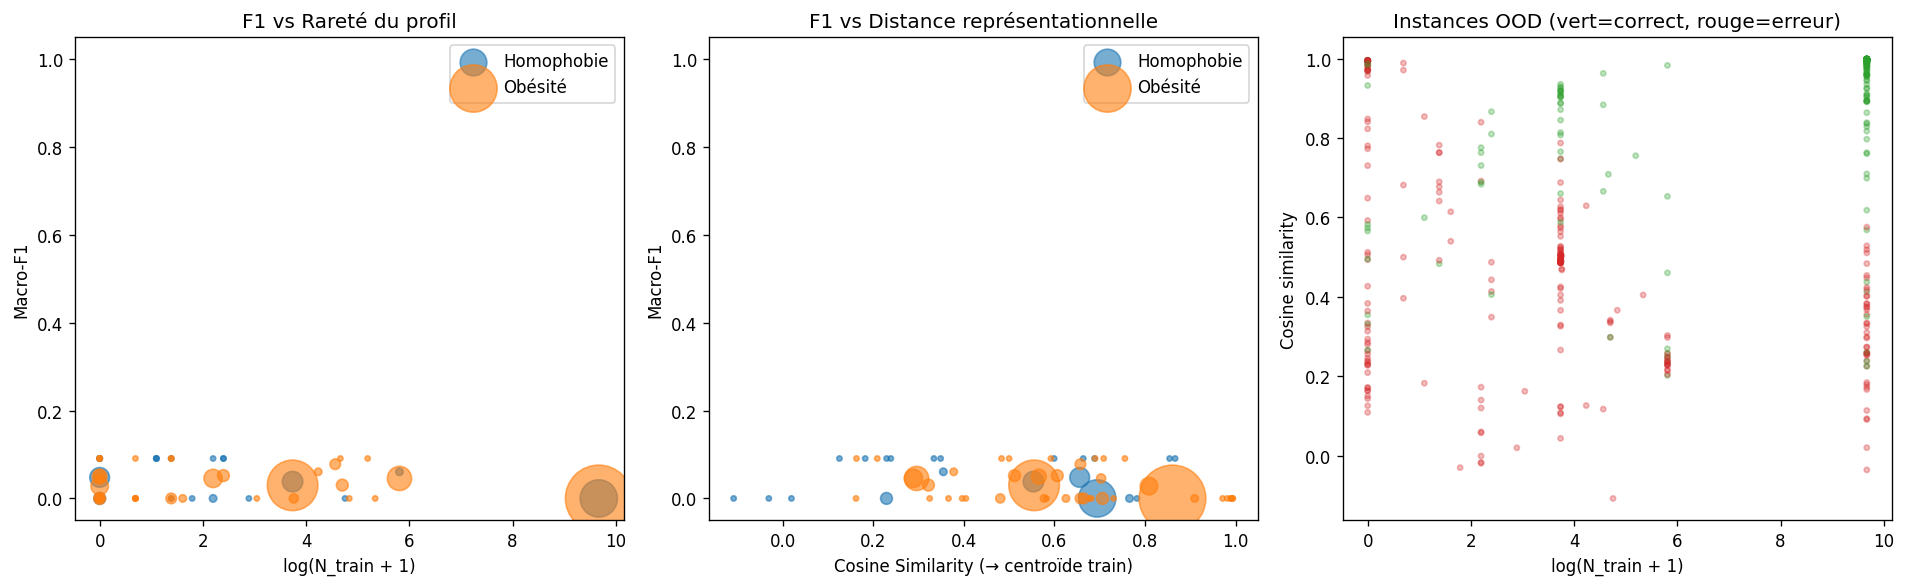

✓ Figure sauvegardée : outputs/rarity_vs_distance.png


In [17]:
# ══════════════════════════════════════════════════════════════════════
# 3.3  Rareté vs Distance — Régression & Visualisation
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
from sklearn.linear_model import LinearRegression, LogisticRegression
from scipy.stats import pearsonr

# ═══════════ A. Régression linéaire per-profil ═══════════
# Y = Macro-F1 per profile ; X1 = log(N_train+1), X2 = mean_cos_centroid
df_reg = df_all_profiles.copy()
df_reg["log_n_train"] = np.log1p(df_reg["n_train"])

X = df_reg[["log_n_train", "mean_cos_centroid"]].values
y = df_reg["macro_f1"].values

print("=" * 80)
print("  A. RÉGRESSION LINÉAIRE : F1 ~ log(N_train+1) + cosine_similarity")
print("=" * 80)

if len(X) >= 5:
    lr = LinearRegression().fit(X, y)
    y_hat = lr.predict(X)
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    print(f"  R² = {r2:.4f}")
    print(f"  Intercept = {lr.intercept_:.4f}")
    print(f"  β(log_n_train)       = {lr.coef_[0]:+.4f}")
    print(f"  β(mean_cos_centroid) = {lr.coef_[1]:+.4f}")
    print()

    # Importance relative (standardized coefficients)
    X_std = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-10)
    lr_std = LinearRegression().fit(X_std, y)
    print(f"  Coefficients standardisés (importance relative) :")
    print(f"    β*(log_n_train)       = {lr_std.coef_[0]:+.4f}")
    print(f"    β*(mean_cos_centroid) = {lr_std.coef_[1]:+.4f}")
    dominant = "RARETÉ (log N_train)" if abs(lr_std.coef_[0]) > abs(lr_std.coef_[1]) else "DISTANCE (cosine sim.)"
    print(f"\n  ➜ Facteur dominant : {dominant}")
else:
    print("  Pas assez de profils (< 5) pour la régression.")

# ═══════════ B. Régression logistique per-instance ═══════════
print(f"\n{'='*80}")
print("  B. RÉGRESSION LOGISTIQUE PER-INSTANCE : correct ~ log(N_train+1) + cos_sim")
print("=" * 80)

# For each OOD instance: build features (log_n_train of its profile, cos to centroid)
# and label (1 if exact match on 11 emotions, 0 otherwise)
instance_rows = []
for ds_name, emb_ood, gold_ood, logits_ood in [
    ("Homophobie", emb_homo, gold_homo, logits_homo),
    ("Obésité",    emb_obes, gold_obes, logits_obes),
]:
    probs_19 = 1.0 / (1.0 + np.exp(-logits_ood))
    threshold_array = np.array([OPTIMIZED_THRESHOLDS[emo] for emo in EMOTION_ORDER])
    emo_probs = np.zeros((len(gold_ood), len(EMOTION_ORDER)))
    for j, emo in enumerate(EMOTION_ORDER):
        emo_probs[:, j] = probs_19[:, EMOTION_INDICES[emo]]
    pred_emo = (emo_probs >= threshold_array).astype(int)

    emo_col_indices = [LABELS_19.index(e) for e in EMOTION_ORDER]
    gold_emo = gold_ood[:, emo_col_indices]

    for i in range(len(gold_ood)):
        prof = profile_key(gold_ood[i])
        n_train = train_profile_counts.get(prof, 0)

        # Cosine to centroid of same profile in train (or global)
        if prof in train_profile_to_idx:
            tid = np.array(train_profile_to_idx[prof])
            centroid = emb_train[tid].mean(axis=0, keepdims=True)
        else:
            centroid = global_train_centroid
        cos_val = float(cosine_similarity(emb_ood[i:i+1], centroid)[0, 0])

        correct = int(np.array_equal(gold_emo[i], pred_emo[i]))
        instance_rows.append({
            "dataset": ds_name,
            "log_n_train": np.log1p(n_train),
            "cos_centroid": cos_val,
            "correct": correct,
        })

df_inst = pd.DataFrame(instance_rows)
X_inst = df_inst[["log_n_train", "cos_centroid"]].values
y_inst = df_inst["correct"].values

if len(np.unique(y_inst)) >= 2:
    logr = LogisticRegression(max_iter=1000).fit(X_inst, y_inst)
    print(f"  Accuracy           : {logr.score(X_inst, y_inst):.4f}")
    print(f"  β(log_n_train)     : {logr.coef_[0][0]:+.4f}")
    print(f"  β(cos_centroid)    : {logr.coef_[0][1]:+.4f}")
    print(f"  Intercept          : {logr.intercept_[0]:+.4f}")

    X_inst_std = (X_inst - X_inst.mean(axis=0)) / (X_inst.std(axis=0) + 1e-10)
    logr_std = LogisticRegression(max_iter=1000).fit(X_inst_std, y_inst)
    print(f"\n  Coefficients standardisés :")
    print(f"    β*(log_n_train)  : {logr_std.coef_[0][0]:+.4f}")
    print(f"    β*(cos_centroid) : {logr_std.coef_[0][1]:+.4f}")
    dominant_inst = "RARETÉ" if abs(logr_std.coef_[0][0]) > abs(logr_std.coef_[0][1]) else "DISTANCE"
    print(f"\n  ➜ Facteur dominant (per-instance) : {dominant_inst}")
else:
    print("  Toutes les instances sont identiques (correct==0 ou ==1), régression impossible.")

# ═══════════ C. Scatter plots ═══════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# C.1: F1 vs log(N_train+1) per profile
ax = axes[0]
for ds_label, df_sub in [("Homophobie", df_sim_homo), ("Obésité", df_sim_obes)]:
    x = np.log1p(df_sub["n_train"].values)
    y_plot = df_sub["macro_f1"].values
    sizes = df_sub["n_ood"].values * 10
    ax.scatter(x, y_plot, s=sizes, alpha=0.6, label=ds_label)
ax.set_xlabel("log(N_train + 1)")
ax.set_ylabel("Macro-F1")
ax.set_title("F1 vs Rareté du profil")
ax.legend()
ax.set_ylim(-0.05, 1.05)

# C.2: F1 vs cosine similarity per profile
ax = axes[1]
for ds_label, df_sub in [("Homophobie", df_sim_homo), ("Obésité", df_sim_obes)]:
    x = df_sub["mean_cos_centroid"].values
    y_plot = df_sub["macro_f1"].values
    sizes = df_sub["n_ood"].values * 10
    ax.scatter(x, y_plot, s=sizes, alpha=0.6, label=ds_label)
ax.set_xlabel("Cosine Similarity (→ centroïde train)")
ax.set_ylabel("Macro-F1")
ax.set_title("F1 vs Distance représentationnelle")
ax.legend()
ax.set_ylim(-0.05, 1.05)

# C.3: Per-instance cos vs log(N_train) colored by correct/incorrect
ax = axes[2]
colors = ["#d62728" if c == 0 else "#2ca02c" for c in df_inst["correct"]]
ax.scatter(df_inst["log_n_train"], df_inst["cos_centroid"],
           c=colors, alpha=0.3, s=10)
ax.set_xlabel("log(N_train + 1)")
ax.set_ylabel("Cosine similarity")
ax.set_title("Instances OOD (vert=correct, rouge=erreur)")

plt.tight_layout()
plt.savefig("outputs/rarity_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : outputs/rarity_vs_distance.png")

  A. EXPECTED CALIBRATION ERROR (ECE)

  Dataset                    ECE (19 labels)  ECE (11 émotions)
  --------------------------------------------------------------
  EmoTextToKids (train)               0.0470             0.0080
  Homophobie                          0.1755             0.0766
  Obésité                             0.1470             0.0575

  B. ECE PAR ÉMOTION (11 émotions)
  Émotion          EmoTextToKids (train)             Homophobie                Obésité
  --------------------------------------------------------------------------------
  Colère                          0.0082                 0.3558                 0.3755
  Dégoût                          0.0016                 0.2557                 0.0730
  Joie                            0.0064                 0.0283                 0.0381
  Peur                            0.0087                 0.0057                 0.0098
  Surprise                        0.0059                 0.0106                 0.0052

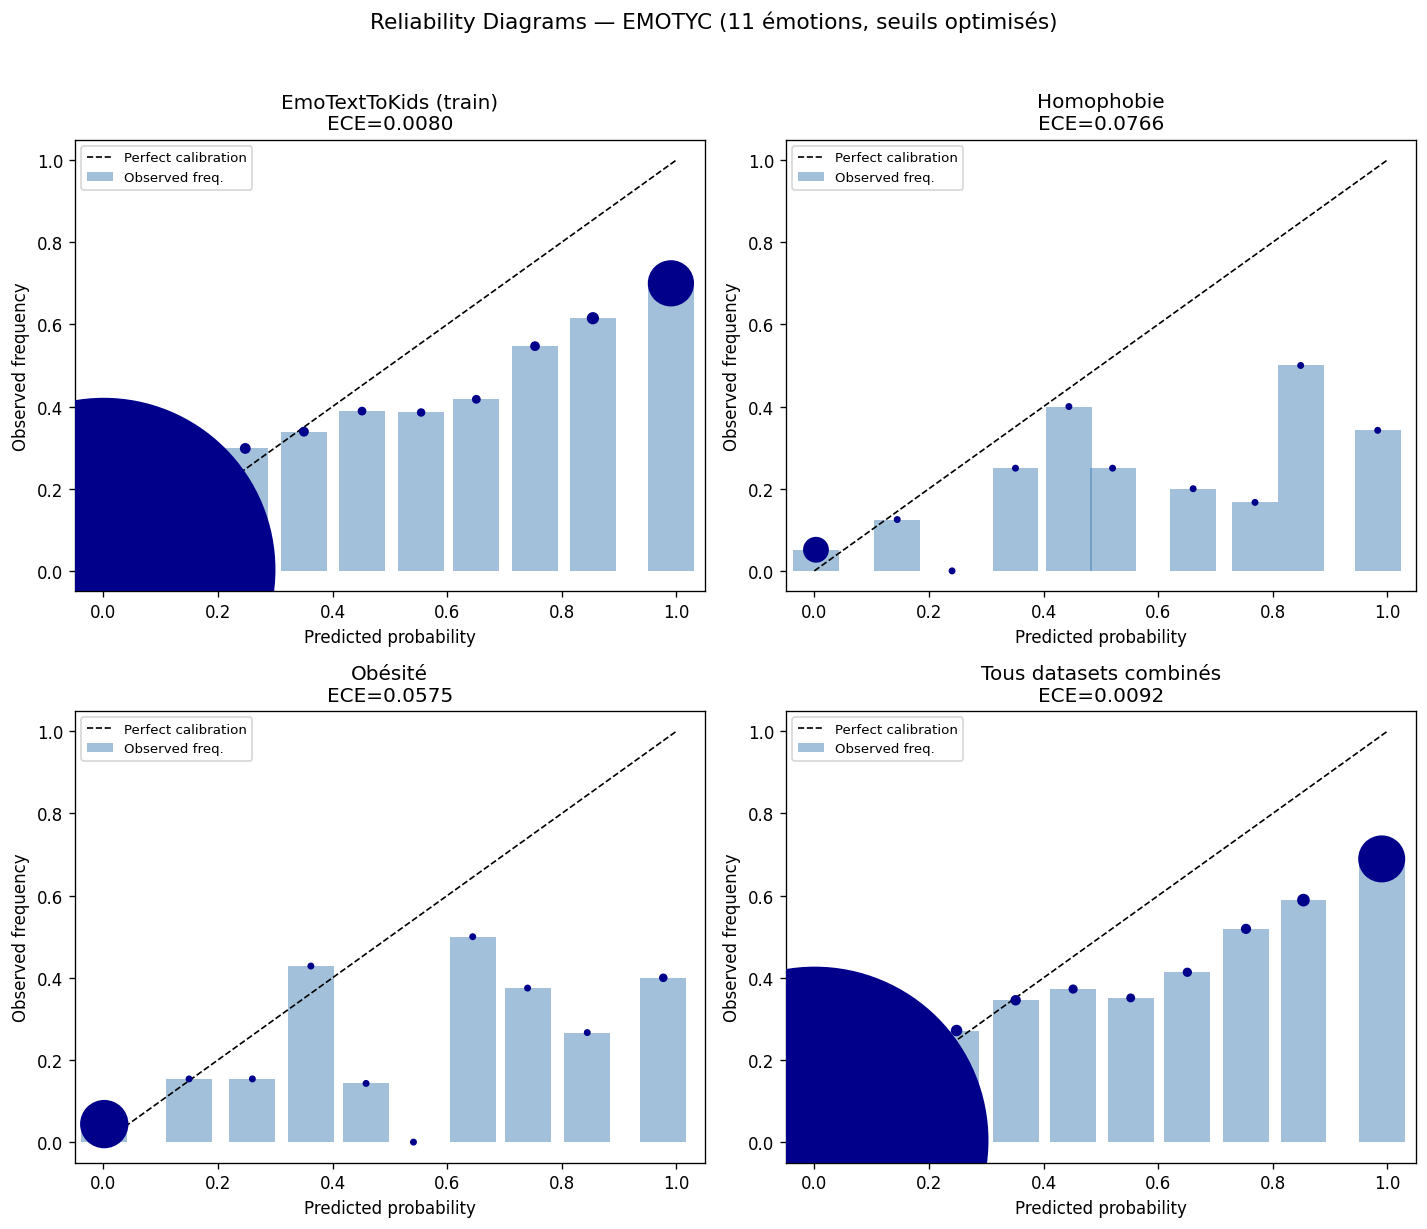


✓ Reliability diagrams sauvegardés : outputs/reliability_diagrams.png
✓ Pipeline Phase 3 terminé.


In [18]:
# ══════════════════════════════════════════════════════════════════════
# 3.4  Calibration — ECE & Reliability Diagrams
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

def compute_ece(probs_flat, labels_flat, n_bins=10):
    """
    Expected Calibration Error.
    probs_flat  : array de probabilités prédites (après sigmoid)
    labels_flat : array de vrais labels binaires (0/1)
    Retourne ECE, et les données par bin pour le reliability diagram.
    """
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_data = []
    ece = 0.0
    total = len(probs_flat)
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        mask = (probs_flat >= lo) & (probs_flat < hi) if b < n_bins - 1 \
               else (probs_flat >= lo) & (probs_flat <= hi)
        n_b = mask.sum()
        if n_b == 0:
            bin_data.append((0.5 * (lo + hi), 0, 0, 0))
            continue
        avg_conf = probs_flat[mask].mean()
        avg_acc = labels_flat[mask].mean()
        ece += (n_b / total) * abs(avg_conf - avg_acc)
        bin_data.append((avg_conf, avg_acc, n_b, n_b / total))
    return ece, bin_data


def get_all_probs_and_labels(logits, gold_19):
    """Retourne (probs_flat, labels_flat) pour les 19 labels."""
    probs_19 = 1.0 / (1.0 + np.exp(-logits))  # sigmoid
    return probs_19.ravel(), gold_19.ravel().astype(float)


def get_emotion_probs_and_labels(logits, gold_19):
    """Retourne (probs_flat, labels_flat) pour les 11 émotions seulement."""
    probs_19 = 1.0 / (1.0 + np.exp(-logits))
    emo_probs = np.zeros((logits.shape[0], len(EMOTION_ORDER)))
    emo_col_indices = [LABELS_19.index(e) for e in EMOTION_ORDER]
    emo_gold = gold_19[:, emo_col_indices]
    for j, emo in enumerate(EMOTION_ORDER):
        emo_probs[:, j] = probs_19[:, EMOTION_INDICES[emo]]
    return emo_probs.ravel(), emo_gold.ravel().astype(float)


# ═══════════ A. ECE globale par dataset ═══════════
print("=" * 80)
print("  A. EXPECTED CALIBRATION ERROR (ECE)")
print("=" * 80)

ds_list = [
    ("EmoTextToKids (train)", logits_train, gold_train),
    ("Homophobie",            logits_homo,  gold_homo),
    ("Obésité",               logits_obes,  gold_obes),
]

ece_results = {}
print(f"\n  {'Dataset':<25s} {'ECE (19 labels)':>16s} {'ECE (11 émotions)':>18s}")
print(f"  {'-'*62}")

for ds_name, logits, gold in ds_list:
    p_all, l_all = get_all_probs_and_labels(logits, gold)
    ece_all, _ = compute_ece(p_all, l_all)

    p_emo, l_emo = get_emotion_probs_and_labels(logits, gold)
    ece_emo, _ = compute_ece(p_emo, l_emo)

    ece_results[ds_name] = (ece_all, ece_emo)
    print(f"  {ds_name:<25s} {ece_all:>16.4f} {ece_emo:>18.4f}")


# ═══════════ B. ECE par émotion ═══════════
print(f"\n{'='*80}")
print("  B. ECE PAR ÉMOTION (11 émotions)")
print("=" * 80)

header = f"  {'Émotion':<15s}"
for ds_name, _, _ in ds_list:
    header += f" {ds_name:>22s}"
print(header)
print("  " + "-" * 80)

for j, emo in enumerate(EMOTION_ORDER):
    row = f"  {emo:<15s}"
    for ds_name, logits, gold in ds_list:
        probs_19 = 1.0 / (1.0 + np.exp(-logits))
        p_emo_j = probs_19[:, EMOTION_INDICES[emo]]
        emo_col_idx = LABELS_19.index(emo)
        l_emo_j = gold[:, emo_col_idx].astype(float)
        ece_j, _ = compute_ece(p_emo_j, l_emo_j)
        row += f" {ece_j:>22.4f}"
    print(row)


# ═══════════ C. Reliability Diagrams (2×2) ═══════════
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# First 3 subplots: individual datasets (11 emotions)
for idx, (ds_name, logits, gold) in enumerate(ds_list):
    ax = axes[idx]
    p_emo, l_emo = get_emotion_probs_and_labels(logits, gold)
    _, bin_data = compute_ece(p_emo, l_emo)

    confs = [b[0] for b in bin_data if b[2] > 0]
    accs  = [b[1] for b in bin_data if b[2] > 0]
    sizes = [b[2] for b in bin_data if b[2] > 0]

    ax.bar(confs, accs, width=0.08, alpha=0.5, color="steelblue", label="Observed freq.")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.scatter(confs, accs, s=[max(10, s/5) for s in sizes], color="darkblue", zorder=3)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ece_val = ece_results[ds_name][1]
    ax.set_title(f"{ds_name}\nECE={ece_val:.4f}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

# 4th subplot: all datasets combined
ax = axes[3]
all_probs, all_labels = [], []
for ds_name, logits, gold in ds_list:
    p_emo, l_emo = get_emotion_probs_and_labels(logits, gold)
    all_probs.append(p_emo)
    all_labels.append(l_emo)
all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
ece_combined, bin_data_combined = compute_ece(all_probs, all_labels)

confs = [b[0] for b in bin_data_combined if b[2] > 0]
accs  = [b[1] for b in bin_data_combined if b[2] > 0]
sizes = [b[2] for b in bin_data_combined if b[2] > 0]

ax.bar(confs, accs, width=0.08, alpha=0.5, color="steelblue", label="Observed freq.")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.scatter(confs, accs, s=[max(10, s/5) for s in sizes], color="darkblue", zorder=3)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title(f"Tous datasets combinés\nECE={ece_combined:.4f}")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)

plt.suptitle("Reliability Diagrams — EMOTYC (11 émotions, seuils optimisés)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("outputs/reliability_diagrams.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ Reliability diagrams sauvegardés : outputs/reliability_diagrams.png")
print(f"✓ Pipeline Phase 3 terminé.")